<a href="https://colab.research.google.com/github/lizzietsitsishvili/ECON3916-Statistical-Machine-Learning/blob/main/Final%20Project/ECON_3916_ML_Prediction_Project_(checkpoint)%E2%80%94_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict housing prices based on property characteristics such as median income, location, and housing features?

**This is a prediction (umbrella) problem because:** This problem focuses on forecasting housing prices using observable features in the dataset. The goal is not to determine whether these variables cause housing prices to change, but rather to build a model that can predict prices as accurately as possible from available information.

**The decision this enables:**
This analysis would help real estate investors and home buyers estimate housing prices more accurately and make better purchasing or investment decisions.

**Dataset:** California Housing Dataset
- **Source:** Scikit-learn built-in dataset (URL: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)
- **N =** 20640
- **Features =** 8
- **Target variable =** Median house value
- **Access date:** April 20, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

# df = pd.read_csv('your_data.csv')
# df = pd.read_csv('https://example.com/data.csv')

# Using sklearn built-in dataset instead of CSV
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['price'] = data.target

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'price']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2.2 Basic Description

In [3]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


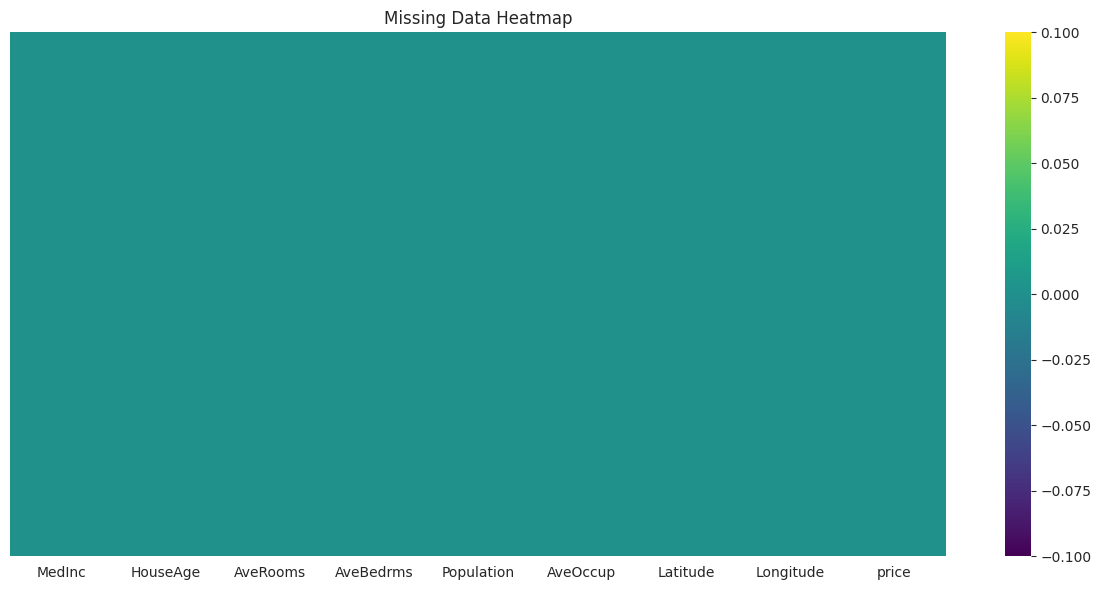

In [4]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# # Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** There are no missing values in this dataset. Therefore, the missingness can be considered MCAR (Missing Completely at Random), and no imputation or data removal is required.

### 2.4 Distribution Plots

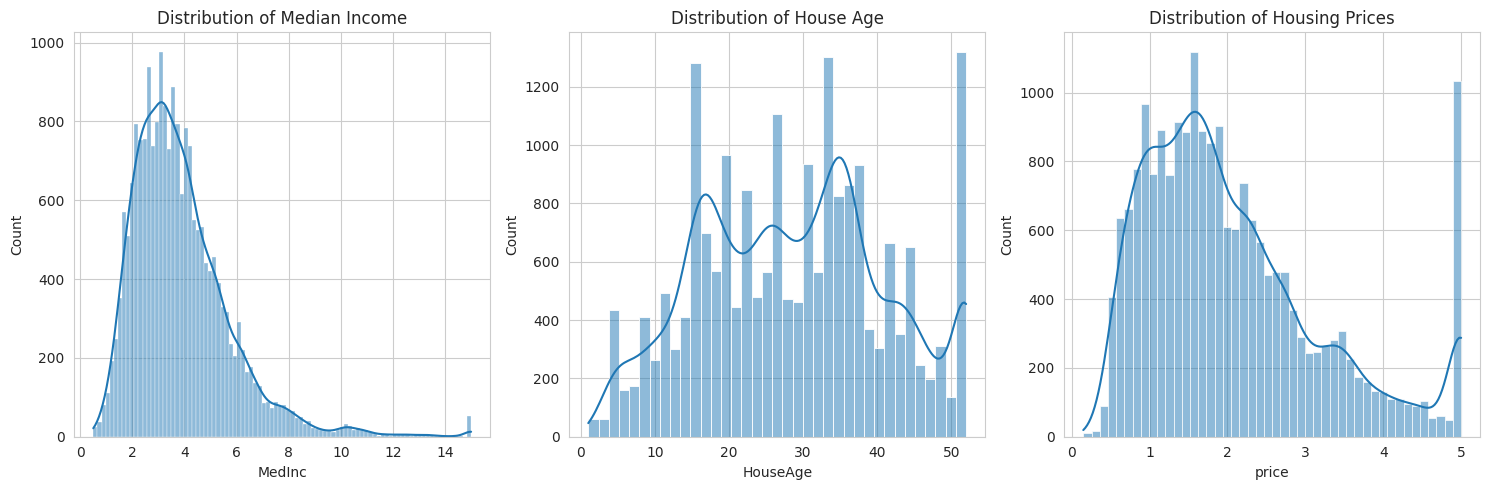

In [5]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# Plot distributions for key features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Feature 1: Median Income
sns.histplot(df['MedInc'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Median Income')

# Feature 2: House Age
sns.histplot(df['HouseAge'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of House Age')

# Target: Price
sns.histplot(df['price'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Housing Prices')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [6]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Check outliers in Median Income
col = 'MedInc'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]

print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

MedInc: 681 outliers (3.3%)


**Outlier strategy:** Outliers were identified using Tukey fences (IQR method). Since these values may represent real high-income areas rather than data errors, I will keep them in the dataset to preserve important variation.

### 2.6 Correlations

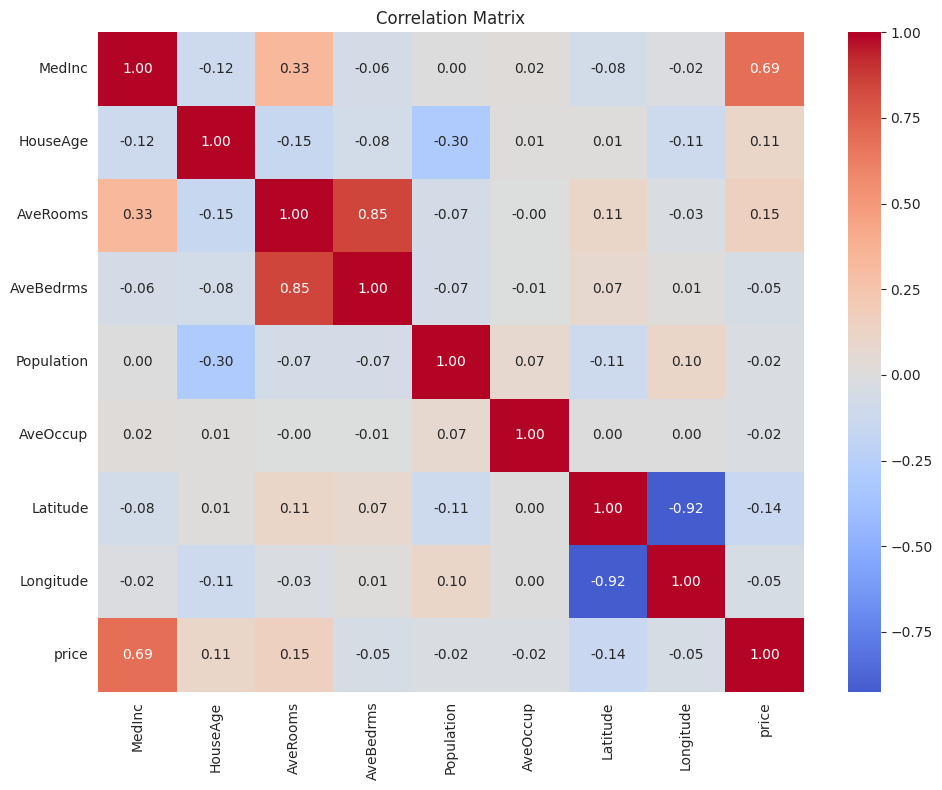

In [7]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

The target variable (housing prices) is right-skewed, with most observations concentrated at lower values and fewer high-price observations. Since this is a regression problem, the skewness does not prevent modeling, but transformations could be considered in future improvements.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

Median income (MedInc) shows the strongest positive correlation with housing prices (around 0.69). Other features have weaker relationships. There is also a strong negative correlation between latitude and longitude, indicating potential multicollinearity between geographic features.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

The main data quality issue is the presence of outliers in variables such as median income. However, these values likely reflect real high-income regions rather than errors, so they are retained to preserve meaningful variation in the dataset.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 20,640** observations and **M = 9** features.

**Missing data:** 0% of cells are missing. The missingness pattern can be considered MCAR (Missing Completely at Random) because there are no missing values in the dataset. I will handle missing data by taking no action.

**Outliers:** I identified 681 outliers (approximately 3.3%) using Tukey Fences (IQR method) on the median income variable. I will handle them by retaining them, as they likely represent real high-income regions rather than data errors.

**Target variable:** The target variable (housing prices) is right-skewed, with most observations concentrated at lower values and fewer high-value observations.

**Key finding from EDA:** Median income is the strongest predictor of housing prices, showing a clear positive relationship with the target variable.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [8]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# Define features and target
X = df.drop('price', axis=1)   # all features
y = df['price']                # target variable

# Train/test split (regression → NO stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 16512 samples
Test:  4128 samples


### 3.2 Model 1: Baseline

In [9]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Fit model
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

# Predictions
y_pred_1 = model_1.predict(X_test)

# Regression metrics
print('Model 1: Linear Regression')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Linear Regression
RMSE: 0.7456
MAE:  0.5332
R2:   0.5758


### 3.3 Model 2: Your Choice

In [ ]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

# from sklearn.ensemble import RandomForestClassifier  # or RandomForestRegressor
#
# model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
# model_2.fit(X_train, y_train)
#
# y_pred_2 = model_2.predict(X_test)
#
# print('Model 2: Random Forest')
# print(classification_report(y_test, y_pred_2))

### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
# scoring = 'accuracy'
#
# cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
# cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
#
# print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
# print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
#
# # Comparison table
# comparison = pd.DataFrame({
#     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
#     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
#     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
# })
# comparison

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___